In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -o telco-customer-churn.zip

Saving archive (1).zip to archive (1) (1).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [ ]:


df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())

print(df.shape)

print(df.columns)
# Data Cleaning
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df.fillna(df["TotalCharges"].median(), inplace=True)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

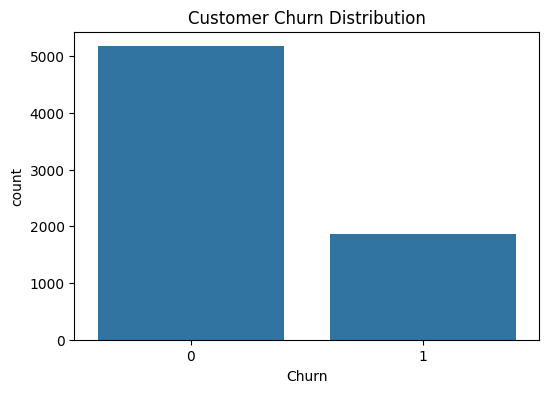

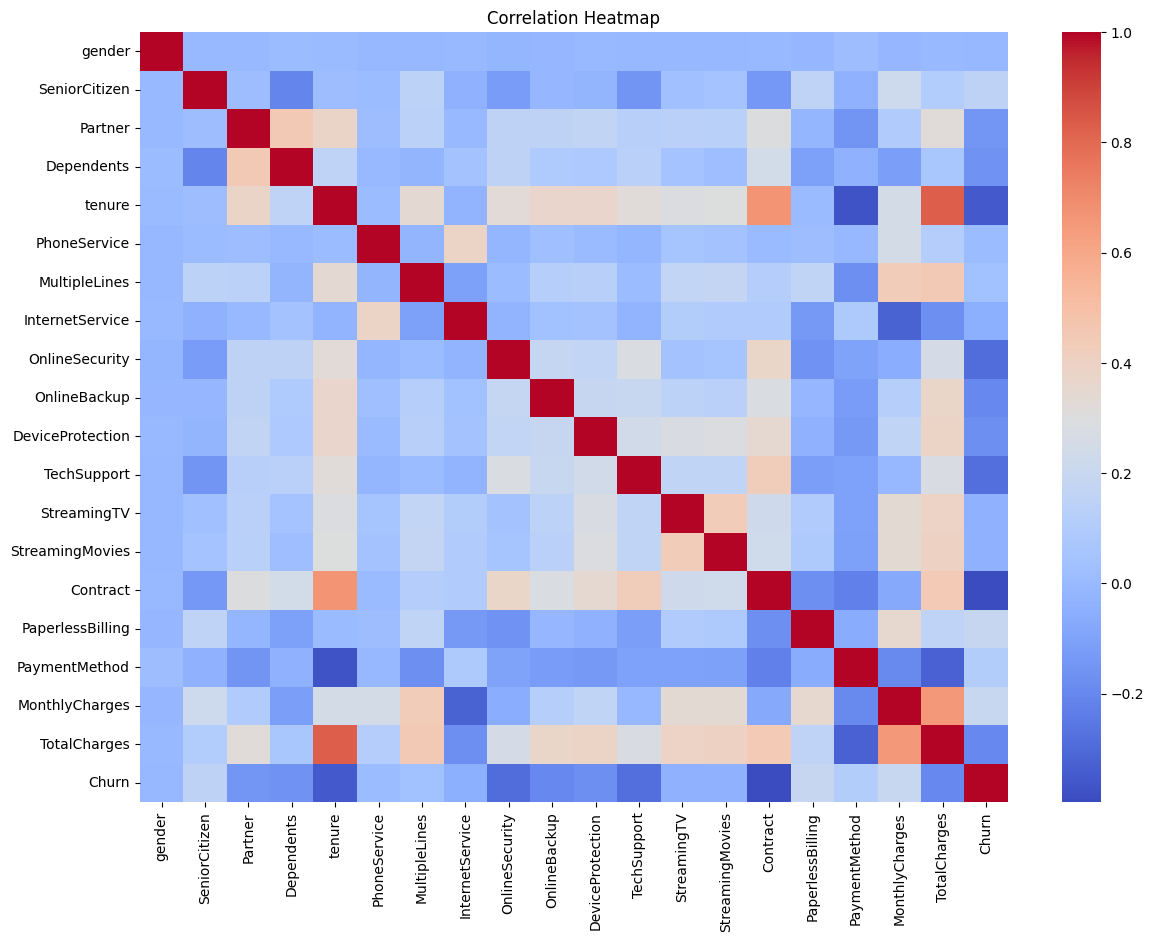

In [ ]:

# Encoding
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])
# EDA

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Features and Target
X = df.drop("Churn", axis=1)

y = df["Churn"]
# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)



Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



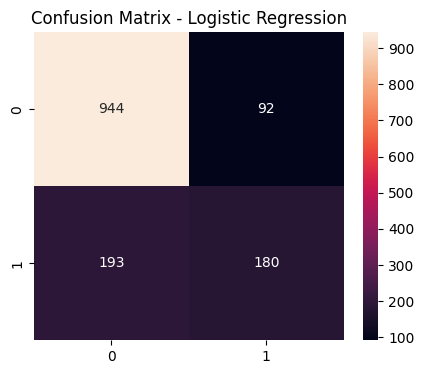


Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.48      0.47      0.48       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



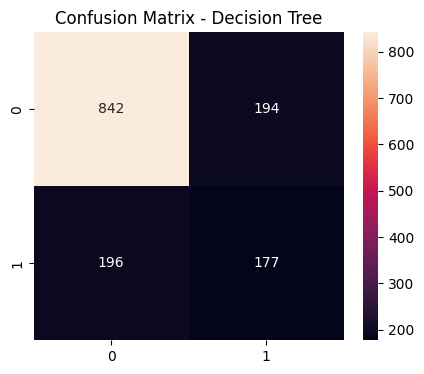


Random Forest
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1036
           1       0.54      0.47      0.50       373

    accuracy                           0.76      1409
   macro avg       0.68      0.66      0.67      1409
weighted avg       0.75      0.76      0.75      1409



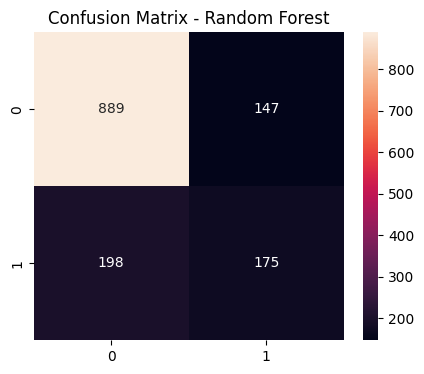


KNN
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1036
           1       0.60      0.48      0.53       373

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



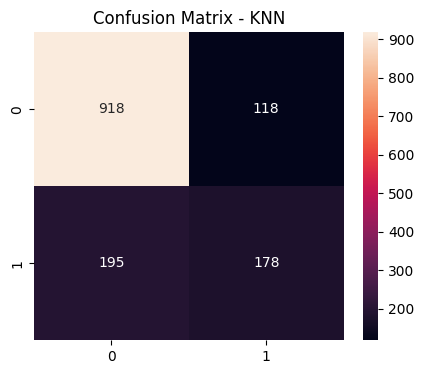


Naive Bayes
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1036
           1       0.69      0.43      0.53       373

    accuracy                           0.80      1409
   macro avg       0.76      0.68      0.70      1409
weighted avg       0.79      0.80      0.78      1409



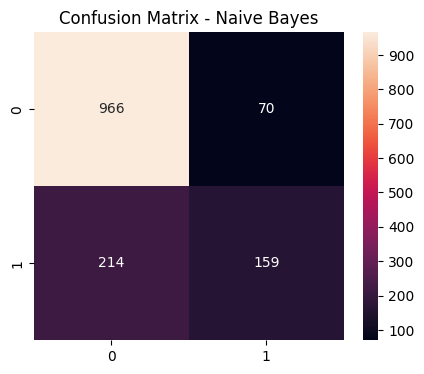

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.797729   0.661765  0.482574  0.558140
1        Decision Tree  0.723208   0.477089  0.474531  0.475806
2        Random Forest  0.755145   0.543478  0.469169  0.503597
3                  KNN  0.777857   0.601351  0.477212  0.532138
4          Naive Bayes  0.798439   0.694323  0.426273  0.528239


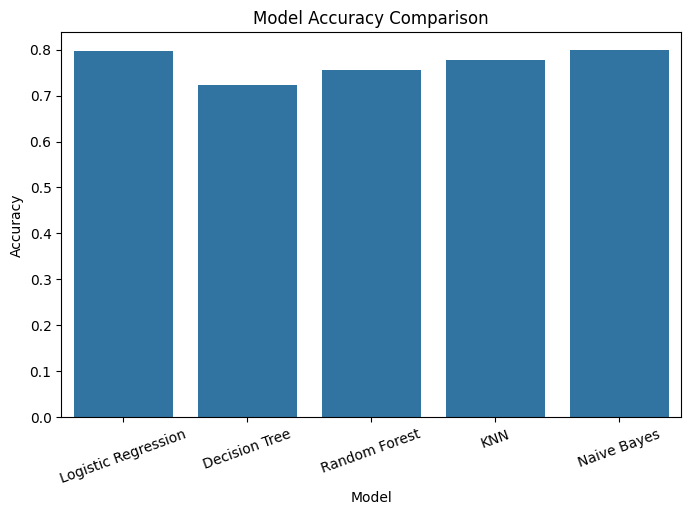

In [ ]:
# SUPERVISED LEARNING
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB()
}
results = []
for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred
    )

    recall = recall_score(
        y_test,
        pred
    )

    f1 = f1_score(
        y_test,
        pred
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\n====================")
    print(name)
    print("====================")

    print(
        classification_report(
            y_test,
            pred
        )
    )

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.show()
# Comparison Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)
print(results_df)
# Accuracy Comparison Graph
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=20)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()
# Features and Target
X = df.drop("Churn", axis=1)

y = df["Churn"]
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


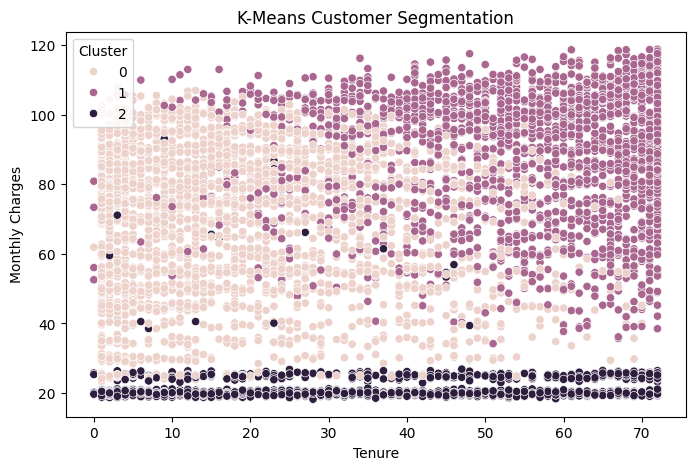

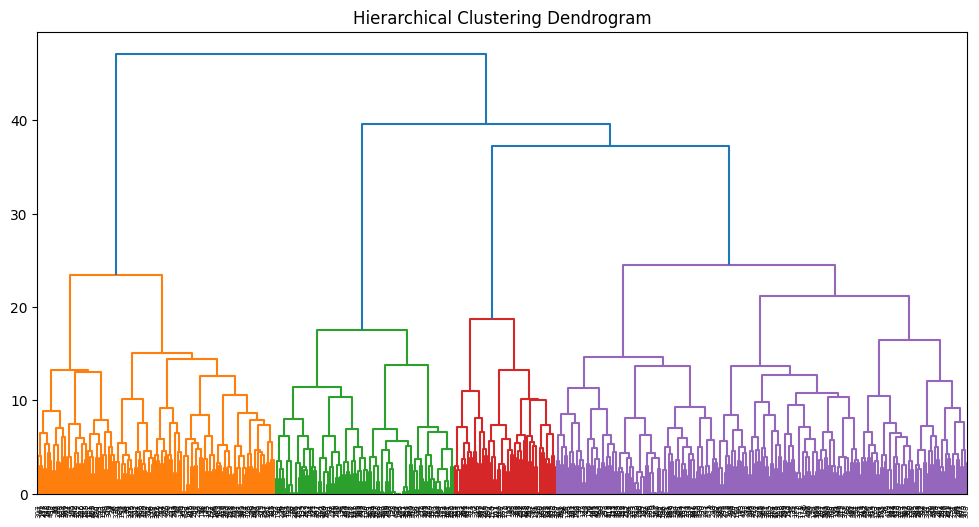

           gender  SeniorCitizen   Partner  Dependents     tenure  \
Cluster                                                             
0        0.502051       0.205112  0.316188    0.183654  16.442726   
1        0.504303       0.189759  0.707401    0.371343  55.419966   
2        0.510968       0.032903  0.487742    0.429032  30.378710   

         PhoneService  MultipleLines  InternetService  OnlineSecurity  \
Cluster                                                                 
0            0.854213       0.820448         0.547176        0.425371   
1            0.908348       1.435026         0.584337        1.139845   
2            0.995484       0.444516         1.971613        1.010968   

         OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
Cluster                                                             
0            0.514989          0.450615     0.394446     0.613443   
1            1.374785          1.457401     1.204389     1.490964   
2           

In [ ]:

# UNSUPERVISED LEARNING
# K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

df["Cluster"] = clusters
# Cluster Visualization
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["tenure"],
    y=df["MonthlyCharges"],
    hue=df["Cluster"]
)

plt.title(
    "K-Means Customer Segmentation"
)

plt.xlabel("Tenure")

plt.ylabel("Monthly Charges")

plt.show()
# Hierarchical Clustering

linked = linkage(
    X_scaled[:500],
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.show()

# Cluster Analysis

print(
    df.groupby("Cluster").mean()
)
# BUSINESS INSIGHTS
print("\nBusiness Insights")

print(
    "1. Identify high churn customers."
)

print(
    "2. Target risky customers with discounts."
)

print(
    "3. Use clusters for marketing campaigns."
)

print(
    "4. Retain customers with high monthly charges."
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

# Sirf 2 features
X = df[["tenure", "MonthlyCharges"]]

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

joblib.dump(rf, "random_forest_model.pkl")

print("Model Saved")
import os
print(os.listdir())
model = joblib.load("random_forest_model.pkl")

Model Saved
['.config', 'random_forest_model.pkl', 'app.py', 'archive (1) (1).zip', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'telco-customer-churn.zip', 'streamlit_log.txt', 'model.pkl', 'archive (1).zip', 'sample_data']
